<a href="https://colab.research.google.com/github/keshav-geu/flyrank-internship/blob/main/work/notebooks/capstone_refresh_opportunity_scoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone: Refresh / Content Opportunity Scoring

## Research Question

Can historical search and content signals help identify pages showing declining performance patterns, so that content teams can prioritize which pages should be reviewed for refresh first?

## Decision Supported

The goal of this project is to produce a ranked list of pages for content review, rather than to automatically decide which pages should be rewritten or refreshed.

## Lane Selection

**Selected Lane:** Refresh / Content Opportunity Scoring

This capstone focuses on identifying pages that may deserve content review based on historical search and content signals.

The final output will be a ranked recommendation system that helps prioritize pages for review using model scores and interpretable reason codes.

## Data Source and Modeling Unit

This project uses the FlyRank ML Internship warehouse release accessed through Hugging Face.

The modeling unit is one content page per row. Historical search-performance and content features will be aggregated for each page before modeling.

Published outputs will remain public-safe: no client names, domains, URLs, private queries, credentials, or raw exports will be included.

## Target Definition

The target is whether a page is showing a declining performance trend.

A page is labeled as:

- **1 = Declining**
- **0 = Not declining**

The decline label is based on the warehouse field `trend_direction`, where:

`trend_direction == "down"` → 1

This target is used only as an observed proxy for prioritization. It does not mean that a page definitely needs to be rewritten, and it does not prove that a refresh would improve rankings.

## Candidate Features

The initial model will use historical signals that are available before the review decision is made.

Candidate features:

- `content_age_days`
- `days_since_last_update`
- `impressions_90d`
- `avg_position`
- `ctr`
- `word_count`

Potential leakage fields such as `trend_direction` and `trend_pct` will not be used as model inputs because they directly describe the target outcome.

## Validation Strategy

To evaluate whether the model generalizes beyond the clients seen during training, the data will be split by client rather than by random rows.

A grouped train/test split will be used so that pages from the same client do not appear in both training and test data.

This reduces the risk of overly optimistic results caused by client-specific patterns leaking across the split.

In [1]:
import pandas as pd
import numpy as np
import duckdb

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
import os
from getpass import getpass

HF_TOKEN = getpass("Paste your Hugging Face READ token: ")

con = duckdb.connect()

con.execute(f"""
CREATE OR REPLACE SECRET hf (
    TYPE huggingface,
    TOKEN '{HF_TOKEN}'
);
""")

print("Hugging Face authentication configured.")

Paste your Hugging Face READ token: ··········
Hugging Face authentication configured.


In [4]:
REL = "hf://datasets/FlyRank/internship-warehouse"

test_df = con.execute(f"""
SELECT *
FROM read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')
LIMIT 5
""").df()

test_df

,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events,month
0,2025-01-27,client_9958f0a7ae1df715,content_3b70a18ea133b2bb,True,True,True,False,30,0,115,...,0,0,0,0,0,0,0,0,0,2025-01
1,2025-01-27,client_9958f0a7ae1df715,content_fe8e8155ce1d47a2,True,True,True,False,5,0,358,...,0,0,0,0,0,0,0,0,0,2025-01
2,2025-01-27,client_9958f0a7ae1df715,content_b4462a1b90640058,True,True,True,False,1,0,34,...,0,0,0,0,0,0,0,0,0,2025-01
3,2025-01-27,client_9958f0a7ae1df715,content_c899aef92518c714,True,True,True,False,6,0,140,...,0,0,0,0,0,0,0,0,0,2025-01
4,2025-01-27,client_9958f0a7ae1df715,content_c7c1d2e68d9d0964,True,True,True,False,5,0,89,...,0,0,0,0,0,0,0,0,0,2025-01


In [5]:
test_df.columns.tolist()

['report_date',
 'client_hash_id',
 'content_hash_id',
 'client_has_gsc',
 'client_has_ga4',
 'gsc_data_available',
 'ga4_data_available',
 'gsc_impressions',
 'gsc_clicks',
 'gsc_sum_position',
 'gsc_avg_position',
 'ga4_pageviews',
 'ga4_sessions',
 'ga4_users',
 'ga4_engaged_sessions',
 'ga4_total_engagement_sec',
 'sessions_organic',
 'sessions_direct',
 'sessions_referral',
 'sessions_social',
 'sessions_paid',
 'sessions_ai',
 'ai_chatgpt',
 'ai_perplexity',
 'ai_gemini',
 'ai_copilot',
 'ai_claude',
 'ai_meta',
 'ai_other',
 'scroll_events',
 'month']

In [6]:
content_dim = con.execute(f"""
SELECT *
FROM read_parquet('{REL}/dim_content.parquet')
LIMIT 5
""").df()

content_dim.columns.tolist()

['client_hash_id',
 'content_hash_id',
 'keyword_hash_id',
 'url_hash_id',
 'keyword_char_count',
 'keyword_token_count',
 'url_char_count',
 'content_created_date',
 'content_updated_date',
 'content_type',
 'search_volume',
 'competition',
 'competition_level',
 'cpc',
 'main_intent',
 'backlinks',
 'category_count',
 'keyword_created_date',
 'provider_used',
 'model_used',
 'char_count',
 'word_count',
 'last_optimized_date',
 'optimization_eligible_date',
 'is_published',
 'is_deleted']

In [7]:
date_range = con.execute(f"""
SELECT
    MIN(report_date) AS min_date,
    MAX(report_date) AS max_date,
    COUNT(*) AS total_rows,
    COUNT(DISTINCT client_hash_id) AS clients,
    COUNT(DISTINCT content_hash_id) AS content_items
FROM read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')
""").df()

date_range

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,min_date,max_date,total_rows,clients,content_items
0,2025-01-27,2026-06-30,78835655,70,427292


## Modeling Window

The warehouse spans from 2025-01-27 to 2026-06-30.

For this capstone, the modeling period will use the final 90 days of available performance data:

**2026-04-02 to 2026-06-30**

This window is used to summarize recent search performance for each content item while keeping the analysis computationally manageable and reproducible.

In [8]:
model_base = con.execute(f"""
SELECT
    client_hash_id,
    content_hash_id,
    SUM(gsc_impressions) AS impressions_90d,
    SUM(gsc_clicks) AS clicks_90d,
    CASE
        WHEN SUM(gsc_impressions) > 0
        THEN SUM(gsc_clicks) * 1.0 / SUM(gsc_impressions)
        ELSE 0
    END AS ctr,
    AVG(gsc_avg_position) AS avg_position
FROM read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')
WHERE report_date BETWEEN DATE '2026-04-02' AND DATE '2026-06-30'
GROUP BY client_hash_id, content_hash_id
""").df()

model_base.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,client_hash_id,content_hash_id,impressions_90d,clicks_90d,ctr,avg_position
0,client_e547b89c05043229,content_25dfa3e39bc37247,1276.0,9.0,0.007053,8.642429
1,client_e547b89c05043229,content_4f6ed7741dfd65e4,107.0,0.0,0.000000,20.151697
2,client_e547b89c05043229,content_bab118937886d46a,469.0,0.0,0.000000,21.897400
3,client_e547b89c05043229,content_7206e9a3ceefb37a,505.0,1.0,0.001980,22.868828
4,client_e547b89c05043229,content_0587243c78e9468a,228.0,0.0,0.000000,32.633004


In [9]:
model_df = model_base.merge(
    content_dim[
        [
            "client_hash_id",
            "content_hash_id",
            "content_created_date",
            "content_updated_date",
            "word_count",
            "content_type"
        ]
    ],
    on=["client_hash_id", "content_hash_id"],
    how="left"
)

model_df.head()

,client_hash_id,content_hash_id,impressions_90d,clicks_90d,ctr,avg_position,content_created_date,content_updated_date,word_count,content_type
0,client_e547b89c05043229,content_25dfa3e39bc37247,1276.0,9.0,0.007053,8.642429,NaT,NaT,NaN,NaN
1,client_e547b89c05043229,content_4f6ed7741dfd65e4,107.0,0.0,0.000000,20.151697,NaT,NaT,NaN,NaN
2,client_e547b89c05043229,content_bab118937886d46a,469.0,0.0,0.000000,21.897400,NaT,NaT,NaN,NaN
3,client_e547b89c05043229,content_7206e9a3ceefb37a,505.0,1.0,0.001980,22.868828,NaT,NaT,NaN,NaN
4,client_e547b89c05043229,content_0587243c78e9468a,228.0,0.0,0.000000,32.633004,NaT,NaT,NaN,NaN


In [10]:
model_df["content_created_date"] = pd.to_datetime(
    model_df["content_created_date"],
    errors="coerce"
)

model_df["content_updated_date"] = pd.to_datetime(
    model_df["content_updated_date"],
    errors="coerce"
)

reference_date = pd.Timestamp("2026-06-30")

model_df["content_age_days"] = (
    reference_date - model_df["content_created_date"]
).dt.days

model_df["days_since_last_update"] = (
    reference_date - model_df["content_updated_date"]
).dt.days

model_df[
    [
        "content_age_days",
        "days_since_last_update",
        "word_count"
    ]
].head()

,content_age_days,days_since_last_update,word_count
0,NaN,NaN,NaN
1,NaN,NaN,NaN
2,NaN,NaN,NaN
3,NaN,NaN,NaN
4,NaN,NaN,NaN


In [11]:
content_dim = con.execute(f"""
SELECT *
FROM read_parquet('{REL}/dim_content.parquet')
""").df()

content_dim.shape

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(519606, 26)

In [12]:
model_df = model_base.merge(
    content_dim[
        [
            "client_hash_id",
            "content_hash_id",
            "content_created_date",
            "content_updated_date",
            "word_count",
            "content_type"
        ]
    ],
    on=["client_hash_id", "content_hash_id"],
    how="left"
)

model_df[
    [
        "content_hash_id",
        "content_created_date",
        "content_updated_date",
        "word_count",
        "content_type"
    ]
].head()

,content_hash_id,content_created_date,content_updated_date,word_count,content_type
0,content_25dfa3e39bc37247,2025-08-13,2026-02-25,1477,keyword article
1,content_4f6ed7741dfd65e4,2025-08-13,2026-05-27,2849,keyword article
2,content_bab118937886d46a,2025-08-13,2026-05-27,2781,keyword article
3,content_7206e9a3ceefb37a,2025-08-13,2026-05-27,2140,keyword article
4,content_0587243c78e9468a,2025-08-13,2026-05-27,2755,keyword article


In [13]:
model_df["content_created_date"] = pd.to_datetime(
    model_df["content_created_date"],
    errors="coerce"
)

model_df["content_updated_date"] = pd.to_datetime(
    model_df["content_updated_date"],
    errors="coerce"
)

reference_date = pd.Timestamp("2026-06-30")

model_df["content_age_days"] = (
    reference_date - model_df["content_created_date"]
).dt.days

model_df["days_since_last_update"] = (
    reference_date - model_df["content_updated_date"]
).dt.days

model_df[
    [
        "content_age_days",
        "days_since_last_update",
        "word_count"
    ]
].head()

,content_age_days,days_since_last_update,word_count
0,321,125,1477
1,321,34,2849
2,321,34,2781
3,321,34,2140
4,321,34,2755


In [14]:
trend_df = con.execute(f"""
WITH earlier AS (
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS impressions_earlier
    FROM read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')
    WHERE report_date BETWEEN DATE '2026-05-02' AND DATE '2026-05-31'
    GROUP BY client_hash_id, content_hash_id
),

recent AS (
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS impressions_recent
    FROM read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')
    WHERE report_date BETWEEN DATE '2026-06-01' AND DATE '2026-06-30'
    GROUP BY client_hash_id, content_hash_id
)

SELECT
    COALESCE(e.client_hash_id, r.client_hash_id) AS client_hash_id,
    COALESCE(e.content_hash_id, r.content_hash_id) AS content_hash_id,
    COALESCE(impressions_earlier, 0) AS impressions_earlier,
    COALESCE(impressions_recent, 0) AS impressions_recent,
    CASE
        WHEN COALESCE(impressions_recent, 0) < COALESCE(impressions_earlier, 0)
        THEN 1
        ELSE 0
    END AS target_decline
FROM earlier e
FULL OUTER JOIN recent r
USING (client_hash_id, content_hash_id)
""").df()

trend_df.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,client_hash_id,content_hash_id,impressions_earlier,impressions_recent,target_decline
0,client_62f4a7e64f5e0096,content_b90a982ea3d4999d,38.0,11.0,1
1,client_62f4a7e64f5e0096,content_17d994b99d470434,827.0,252.0,1
2,client_62f4a7e64f5e0096,content_9e6d399bb7df2d21,874.0,411.0,1
3,client_62f4a7e64f5e0096,content_8cd2b02ae0c9cca4,7.0,2.0,1
4,client_62f4a7e64f5e0096,content_889961fe0fd51a4b,2664.0,2140.0,1


In [15]:
model_df = model_df.merge(
    trend_df[
        [
            "client_hash_id",
            "content_hash_id",
            "impressions_earlier",
            "impressions_recent",
            "target_decline"
        ]
    ],
    on=["client_hash_id", "content_hash_id"],
    how="inner"
)

model_df[
    [
        "content_hash_id",
        "impressions_90d",
        "impressions_earlier",
        "impressions_recent",
        "target_decline"
    ]
].head()

,content_hash_id,impressions_90d,impressions_earlier,impressions_recent,target_decline
0,content_25dfa3e39bc37247,1276.0,616.0,216.0,1
1,content_4f6ed7741dfd65e4,107.0,34.0,9.0,1
2,content_bab118937886d46a,469.0,173.0,110.0,1
3,content_7206e9a3ceefb37a,505.0,112.0,279.0,0
4,content_0587243c78e9468a,228.0,59.0,48.0,1


In [16]:
model_df["target_decline"].value_counts(dropna=False)

,count
target_decline,
0,223961
1,185365


In [17]:
model_df["target_decline"].value_counts(normalize=True)

,proportion
target_decline,
0,0.547146
1,0.452854


In [18]:
features = [
    "content_age_days",
    "days_since_last_update",
    "impressions_90d",
    "avg_position",
    "ctr",
    "word_count"
]

model_df[features].isna().sum()

,0
content_age_days,0
days_since_last_update,0
impressions_90d,0
avg_position,138681
ctr,0
word_count,107758


In [19]:
model_clean = model_df.dropna(subset=features).copy()

print("Rows before cleaning:", len(model_df))
print("Rows after cleaning:", len(model_clean))
print("Rows removed:", len(model_df) - len(model_clean))

Rows before cleaning: 409326
Rows after cleaning: 210424
Rows removed: 198902


In [20]:
print("Original target distribution:")
print(model_df["target_decline"].value_counts(normalize=True))

print("\nCleaned target distribution:")
print(model_clean["target_decline"].value_counts(normalize=True))

Original target distribution:
target_decline
0    0.547146
1    0.452854
Name: proportion, dtype: float64

Cleaned target distribution:
target_decline
1    0.658608
0    0.341392
Name: proportion, dtype: float64


In [21]:
model_train = model_df.copy()

model_train["avg_position_missing"] = (
    model_train["avg_position"].isna().astype(int)
)

model_train["word_count_missing"] = (
    model_train["word_count"].isna().astype(int)
)

features = [
    "content_age_days",
    "days_since_last_update",
    "impressions_90d",
    "avg_position",
    "ctr",
    "word_count",
    "avg_position_missing",
    "word_count_missing"
]

print("Rows kept:", len(model_train))
print(model_train["target_decline"].value_counts(normalize=True))

Rows kept: 409326
target_decline
0    0.547146
1    0.452854
Name: proportion, dtype: float64


In [22]:
from sklearn.model_selection import GroupShuffleSplit

X = model_train[features]
y = model_train["target_decline"]
groups = model_train["client_hash_id"]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Train clients:", groups.iloc[train_idx].nunique())
print("Test clients:", groups.iloc[test_idx].nunique())

Training rows: 354472
Test rows: 54854
Train clients: 52
Test clients: 14


In [23]:
print("Train decline rate:")
print(y_train.value_counts(normalize=True))

print("\nTest decline rate:")
print(y_test.value_counts(normalize=True))

Train decline rate:
target_decline
0    0.530276
1    0.469724
Name: proportion, dtype: float64

Test decline rate:
target_decline
0    0.65616
1    0.34384
Name: proportion, dtype: float64


In [24]:
median_avg_position = X_train["avg_position"].median()
median_word_count = X_train["word_count"].median()

X_train["avg_position"] = X_train["avg_position"].fillna(
    median_avg_position
)

X_test["avg_position"] = X_test["avg_position"].fillna(
    median_avg_position
)

X_train["word_count"] = X_train["word_count"].fillna(
    median_word_count
)

X_test["word_count"] = X_test["word_count"].fillna(
    median_word_count
)

print("Missing values in training set:")
print(X_train.isna().sum())

print("\nMissing values in test set:")
print(X_test.isna().sum())

Missing values in training set:
content_age_days          0
days_since_last_update    0
impressions_90d           0
avg_position              0
ctr                       0
word_count                0
avg_position_missing      0
word_count_missing        0
dtype: int64

Missing values in test set:
content_age_days          0
days_since_last_update    0
impressions_90d           0
avg_position              0
ctr                       0
word_count                0
avg_position_missing      0
word_count_missing        0
dtype: int64


In [25]:
baseline_test = X_test.copy()

baseline_test["baseline_score"] = (
    baseline_test["impressions_90d"].rank(pct=True)
    + baseline_test["content_age_days"].rank(pct=True)
    + baseline_test["days_since_last_update"].rank(pct=True)
    - baseline_test["ctr"].rank(pct=True)
)

baseline_test["target_decline"] = y_test.values

baseline_test[
    [
        "baseline_score",
        "impressions_90d",
        "content_age_days",
        "days_since_last_update",
        "ctr",
        "target_decline"
    ]
].sort_values(
    "baseline_score",
    ascending=False
).head(10)

,baseline_score,impressions_90d,content_age_days,days_since_last_update,ctr,target_decline
92443,2.446039,5434.0,523,43,0.0,0
90729,2.413662,1913.0,523,43,0.0,0
123136,2.408776,8023.0,481,43,0.0,1
123734,2.407655,3152.0,511,43,0.0,1
133363,2.404182,2841.0,511,43,0.0,1
92679,2.400737,1364.0,523,43,0.0,1
130743,2.399552,5431.0,481,43,0.0,1
90719,2.395678,1205.0,523,43,0.0,1
92785,2.393125,1850.0,379,125,0.0,1
133656,2.393025,1625.0,515,43,0.0,1


In [26]:
def precision_at_k(y_true, scores, k):
    order = np.argsort(np.asarray(scores))[::-1][:k]
    return np.mean(np.asarray(y_true)[order])

baseline_p20 = precision_at_k(
    baseline_test["target_decline"],
    baseline_test["baseline_score"],
    20
)

baseline_p50 = precision_at_k(
    baseline_test["target_decline"],
    baseline_test["baseline_score"],
    50
)

print("Baseline Precision@20:", baseline_p20)
print("Baseline Precision@50:", baseline_p50)

Baseline Precision@20: 0.9
Baseline Precision@50: 0.9


In [27]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

logreg.fit(X_train, y_train)

logreg_scores = logreg.predict_proba(X_test)[:, 1]

logreg_p20 = precision_at_k(y_test, logreg_scores, 20)
logreg_p50 = precision_at_k(y_test, logreg_scores, 50)

print("Logistic Regression Precision@20:", logreg_p20)
print("Logistic Regression Precision@50:", logreg_p50)

Logistic Regression Precision@20: 1.0
Logistic Regression Precision@50: 0.9


In [28]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_scores = rf.predict_proba(X_test)[:, 1]

rf_p20 = precision_at_k(y_test, rf_scores, 20)
rf_p50 = precision_at_k(y_test, rf_scores, 50)

print("Random Forest Precision@20:", rf_p20)
print("Random Forest Precision@50:", rf_p50)

Random Forest Precision@20: 1.0
Random Forest Precision@50: 1.0


In [29]:
results_table = pd.DataFrame({
    "Model": [
        "Baseline",
        "Logistic Regression",
        "Random Forest"
    ],
    "Precision@20": [
        baseline_p20,
        logreg_p20,
        rf_p20
    ],
    "Precision@50": [
        baseline_p50,
        logreg_p50,
        rf_p50
    ]
})

results_table

,Model,Precision@20,Precision@50
0,Baseline,0.9,0.9
1,Logistic Regression,1.0,0.9
2,Random Forest,1.0,1.0


In [30]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

feature_importance

,feature,importance
2,impressions_90d,0.354706
6,avg_position_missing,0.253161
3,avg_position,0.154053
0,content_age_days,0.128185
1,days_since_last_update,0.052186
4,ctr,0.037972
5,word_count,0.012877
7,word_count_missing,0.006859


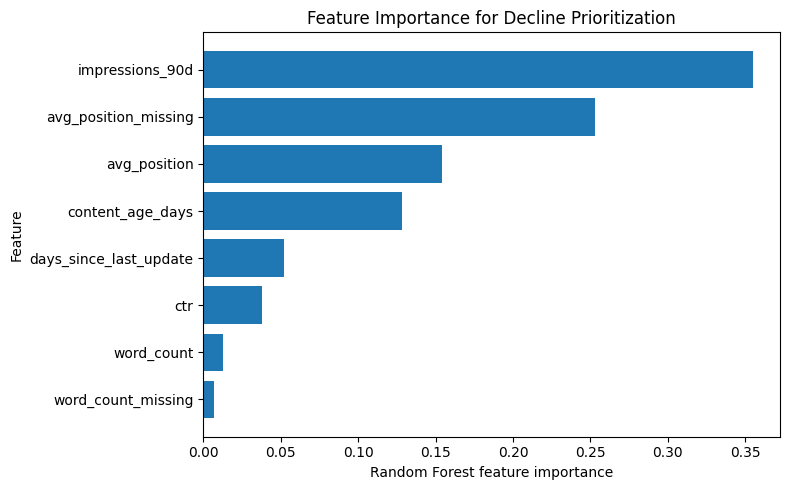

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance["feature"][::-1],
    feature_importance["importance"][::-1]
)

plt.xlabel("Random Forest feature importance")
plt.ylabel("Feature")
plt.title("Feature Importance for Decline Prioritization")

plt.tight_layout()
plt.show()

In [32]:
rf_results = model_train.iloc[test_idx].copy()

rf_results["rf_score"] = rf_scores
rf_results["target_decline"] = y_test.values

top50_rf = rf_results.sort_values(
    "rf_score",
    ascending=False
).head(50)

top50_rf[
    [
        "content_hash_id",
        "rf_score",
        "target_decline",
        "impressions_90d",
        "avg_position",
        "ctr",
        "content_age_days",
        "days_since_last_update",
        "word_count"
    ]
].head(20)

,content_hash_id,rf_score,target_decline,impressions_90d,avg_position,ctr,content_age_days,days_since_last_update,word_count
38056,content_e51e426fdac2c6f8,0.966233,1,1.0,0.0,0.0,319,41,921
38046,content_409e3fed29a6af76,0.966233,1,1.0,0.0,0.0,319,41,917
38065,content_b1fdd284f26e0666,0.966233,1,1.0,0.0,0.0,319,41,925
38034,content_566dc3710a772289,0.966233,1,1.0,0.0,0.0,319,41,921
39726,content_8893625d9acca36b,0.966233,1,1.0,0.0,0.0,319,41,929
39662,content_1c232d94799e400f,0.966233,1,1.0,0.0,0.0,319,41,926
38111,content_88086c5c9380bd63,0.966206,1,1.0,0.0,0.0,319,41,995
38160,content_76b1c0f039083289,0.966184,1,1.0,0.0,0.0,319,41,938
38132,content_3888d3765bba7763,0.966184,1,1.0,0.0,0.0,319,41,939
38080,content_4c5e17c7f2ad011b,0.966171,1,1.0,0.0,0.0,319,41,1003


In [33]:
top50_rf["impressions_90d"].describe()

,impressions_90d
count,50.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


In [34]:
model_base = con.execute(f"""
SELECT
    client_hash_id,
    content_hash_id,
    SUM(gsc_impressions) AS impressions_90d,
    SUM(gsc_clicks) AS clicks_90d,
    CASE
        WHEN SUM(gsc_impressions) > 0
        THEN SUM(gsc_clicks) * 1.0 / SUM(gsc_impressions)
        ELSE 0
    END AS ctr,
    AVG(gsc_avg_position) AS avg_position
FROM read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')
WHERE report_date BETWEEN DATE '2026-03-03' AND DATE '2026-05-31'
GROUP BY client_hash_id, content_hash_id
""").df()

model_base.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,client_hash_id,content_hash_id,impressions_90d,clicks_90d,ctr,avg_position
0,client_625b6439094e23e4,content_85d2ae63012f8927,0.0,0.0,0.0,NaN
1,client_625b6439094e23e4,content_0c4e4bbc8318421c,0.0,0.0,0.0,NaN
2,client_625b6439094e23e4,content_24d913225022fb46,0.0,0.0,0.0,NaN
3,client_625b6439094e23e4,content_0364cee150593313,0.0,0.0,0.0,NaN
4,client_625b6439094e23e4,content_895c7e6fe3cdf278,0.0,0.0,0.0,NaN


In [35]:
model_fixed = model_base.merge(
    content_dim[
        [
            "client_hash_id",
            "content_hash_id",
            "content_created_date"
        ]
    ],
    on=["client_hash_id", "content_hash_id"],
    how="left"
)

model_fixed = model_fixed.merge(
    trend_df[
        [
            "client_hash_id",
            "content_hash_id",
            "impressions_earlier",
            "impressions_recent",
            "target_decline"
        ]
    ],
    on=["client_hash_id", "content_hash_id"],
    how="inner"
)

model_fixed["content_created_date"] = pd.to_datetime(
    model_fixed["content_created_date"],
    errors="coerce"
)

reference_date = pd.Timestamp("2026-05-31")

model_fixed["content_age_days"] = (
    reference_date - model_fixed["content_created_date"]
).dt.days

model_fixed.head()

,client_hash_id,content_hash_id,impressions_90d,clicks_90d,ctr,avg_position,content_created_date,impressions_earlier,impressions_recent,target_decline,content_age_days
0,client_625b6439094e23e4,content_85d2ae63012f8927,0.0,0.0,0.0,NaN,2025-05-04,0.0,0.0,0,392
1,client_625b6439094e23e4,content_0c4e4bbc8318421c,0.0,0.0,0.0,NaN,2025-05-04,0.0,0.0,0,392
2,client_625b6439094e23e4,content_24d913225022fb46,0.0,0.0,0.0,NaN,2025-05-04,0.0,0.0,0,392
3,client_625b6439094e23e4,content_0364cee150593313,0.0,0.0,0.0,NaN,2025-05-04,0.0,0.0,0,392
4,client_625b6439094e23e4,content_895c7e6fe3cdf278,0.0,0.0,0.0,NaN,2025-05-04,0.0,0.0,0,392


In [36]:
model_fixed.loc[
    model_fixed["impressions_earlier"] > 0,
    "impressions_earlier"
].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9]
)

,impressions_earlier
count,237429.000000
mean,1084.880545
std,4884.918274
min,1.000000
25%,8.000000
50%,78.000000
75%,497.000000
90%,2227.200000
max,585502.000000


In [37]:
for threshold in [10, 50, 100, 500]:
    kept = (model_fixed["impressions_earlier"] >= threshold).sum()
    pct = kept / len(model_fixed) * 100

    print(
        f"Threshold >= {threshold:3}: "
        f"{kept:,} rows kept ({pct:.1f}%)"
    )

Threshold >=  10: 173,345 rows kept (44.5%)
Threshold >=  50: 132,651 rows kept (34.1%)
Threshold >= 100: 111,247 rows kept (28.6%)
Threshold >= 500: 59,196 rows kept (15.2%)


In [38]:
model_final = model_fixed[
    model_fixed["impressions_earlier"] >= 50
].copy()

print("Rows in final modeling dataset:", len(model_final))
print("\nTarget distribution:")
print(model_final["target_decline"].value_counts(normalize=True))

Rows in final modeling dataset: 132651

Target distribution:
target_decline
1    0.748325
0    0.251675
Name: proportion, dtype: float64


In [39]:
final_features = [
    "content_age_days",
    "impressions_90d",
    "avg_position",
    "ctr"
]

model_final["avg_position_missing"] = (
    model_final["avg_position"].isna().astype(int)
)

final_features.append("avg_position_missing")

X_final = model_final[final_features].copy()
y_final = model_final["target_decline"].copy()
groups_final = model_final["client_hash_id"]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx_final, test_idx_final = next(
    splitter.split(
        X_final,
        y_final,
        groups=groups_final
    )
)

X_train_final = X_final.iloc[train_idx_final].copy()
X_test_final = X_final.iloc[test_idx_final].copy()

y_train_final = y_final.iloc[train_idx_final].copy()
y_test_final = y_final.iloc[test_idx_final].copy()

print("Training rows:", len(X_train_final))
print("Test rows:", len(X_test_final))
print("Train clients:", groups_final.iloc[train_idx_final].nunique())
print("Test clients:", groups_final.iloc[test_idx_final].nunique())

print("\nTrain decline rate:", y_train_final.mean())
print("Test decline rate:", y_test_final.mean())

Training rows: 88657
Test rows: 43994
Train clients: 42
Test clients: 11

Train decline rate: 0.7583383150794636
Test decline rate: 0.728144747010956


In [40]:
final_avg_position_median = X_train_final["avg_position"].median()

X_train_final["avg_position"] = (
    X_train_final["avg_position"]
    .fillna(final_avg_position_median)
)

X_test_final["avg_position"] = (
    X_test_final["avg_position"]
    .fillna(final_avg_position_median)
)

print("Training missing values:")
print(X_train_final.isna().sum())

print("\nTest missing values:")
print(X_test_final.isna().sum())

print("\nTraining median used:", final_avg_position_median)

Training missing values:
content_age_days        0
impressions_90d         0
avg_position            0
ctr                     0
avg_position_missing    0
dtype: int64

Test missing values:
content_age_days        0
impressions_90d         0
avg_position            0
ctr                     0
avg_position_missing    0
dtype: int64

Training median used: 12.217397433371417


In [41]:
# ----- Baseline -----
baseline_final = X_test_final.copy()

baseline_final["baseline_score"] = (
    baseline_final["impressions_90d"].rank(pct=True)
    + baseline_final["content_age_days"].rank(pct=True)
    - baseline_final["ctr"].rank(pct=True)
)

baseline_final["target_decline"] = y_test_final.values

baseline_final_p20 = precision_at_k(
    baseline_final["target_decline"],
    baseline_final["baseline_score"],
    20
)

baseline_final_p50 = precision_at_k(
    baseline_final["target_decline"],
    baseline_final["baseline_score"],
    50
)

# ----- Logistic Regression -----
logreg_final = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

logreg_final.fit(X_train_final, y_train_final)

logreg_final_scores = logreg_final.predict_proba(
    X_test_final
)[:, 1]

logreg_final_p20 = precision_at_k(
    y_test_final,
    logreg_final_scores,
    20
)

logreg_final_p50 = precision_at_k(
    y_test_final,
    logreg_final_scores,
    50
)

# ----- Random Forest -----
rf_final = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train_final, y_train_final)

rf_final_scores = rf_final.predict_proba(
    X_test_final
)[:, 1]

rf_final_p20 = precision_at_k(
    y_test_final,
    rf_final_scores,
    20
)

rf_final_p50 = precision_at_k(
    y_test_final,
    rf_final_scores,
    50
)

print("Baseline:", baseline_final_p20, baseline_final_p50)
print("Logistic Regression:", logreg_final_p20, logreg_final_p50)
print("Random Forest:", rf_final_p20, rf_final_p50)

Baseline: 0.8 0.74
Logistic Regression: 0.7 0.76
Random Forest: 0.95 0.96


In [42]:
final_results = pd.DataFrame({
    "Method": [
        "Test-set base rate",
        "Baseline",
        "Logistic Regression",
        "Random Forest"
    ],
    "Precision@20": [
        y_test_final.mean(),
        baseline_final_p20,
        logreg_final_p20,
        rf_final_p20
    ],
    "Precision@50": [
        y_test_final.mean(),
        baseline_final_p50,
        logreg_final_p50,
        rf_final_p50
    ]
})

final_results

,Method,Precision@20,Precision@50
0,Test-set base rate,0.728145,0.728145
1,Baseline,0.800000,0.740000
2,Logistic Regression,0.700000,0.760000
3,Random Forest,0.950000,0.960000


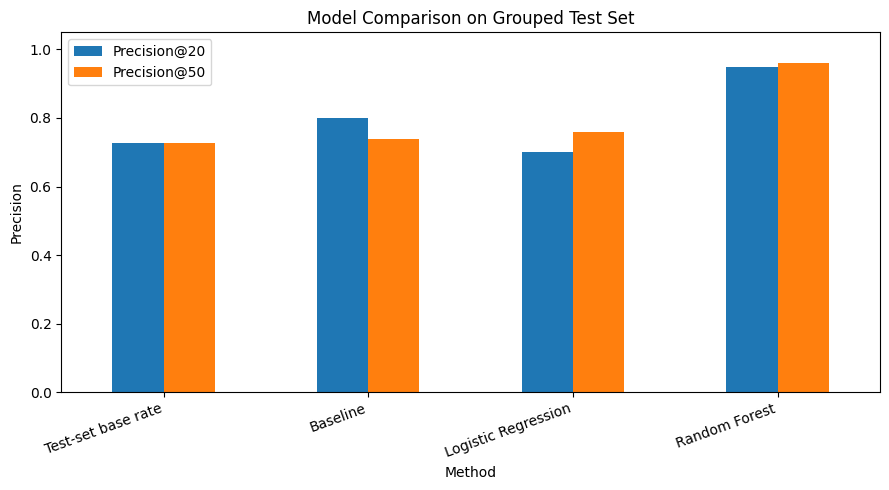

In [43]:
import matplotlib.pyplot as plt

plot_df = final_results.set_index("Method")[["Precision@20", "Precision@50"]]

plot_df.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.ylabel("Precision")
plt.title("Model Comparison on Grouped Test Set")
plt.ylim(0, 1.05)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [44]:
final_feature_importance = pd.DataFrame({
    "feature": X_train_final.columns,
    "importance": rf_final.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

final_feature_importance

,feature,importance
0,content_age_days,0.649348
3,ctr,0.171092
2,avg_position,0.096258
1,impressions_90d,0.083301
4,avg_position_missing,0.000000


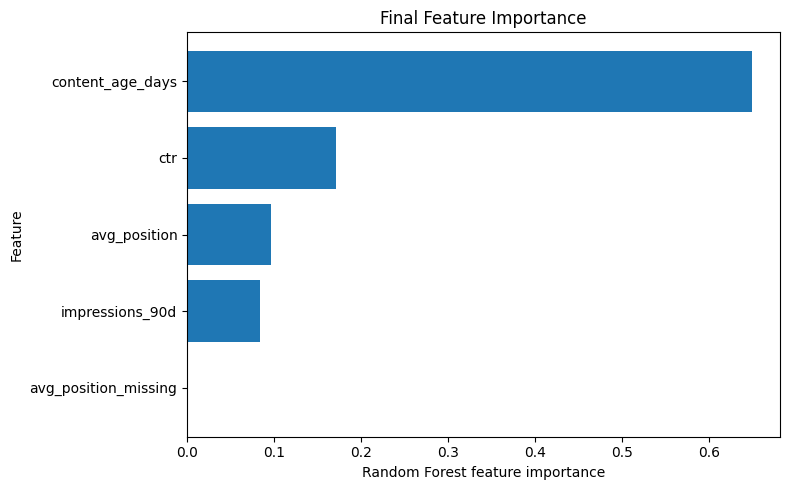

In [45]:
plt.figure(figsize=(8, 5))

plt.barh(
    final_feature_importance["feature"][::-1],
    final_feature_importance["importance"][::-1]
)

plt.xlabel("Random Forest feature importance")
plt.ylabel("Feature")
plt.title("Final Feature Importance")

plt.tight_layout()
plt.show()

In [46]:
final_feature_importance.reset_index(drop=True)

,feature,importance
0,content_age_days,0.649348
1,ctr,0.171092
2,avg_position,0.096258
3,impressions_90d,0.083301
4,avg_position_missing,0.000000


In [47]:
final_ranked = model_final.iloc[test_idx_final].copy()

final_ranked["rf_score"] = rf_final_scores
final_ranked["target_decline"] = y_test_final.values

final_ranked = final_ranked.sort_values(
    "rf_score",
    ascending=False
).reset_index(drop=True)

final_ranked[
    [
        "content_hash_id",
        "rf_score",
        "target_decline",
        "impressions_90d",
        "avg_position",
        "ctr",
        "content_age_days"
    ]
].head(20)


,content_hash_id,rf_score,target_decline,impressions_90d,avg_position,ctr,content_age_days
0,content_696968e3355e1000,0.872735,1,39022.0,20.189294,0.005792,220
1,content_263d186f5e6e0121,0.872422,1,36702.0,16.939712,0.008228,135
2,content_8c32e1bf00aca72b,0.871256,1,48928.0,39.886096,0.000388,142
3,content_f8c15fdc81785708,0.871114,1,30486.0,39.378781,0.000623,135
4,content_ca43be9d1b8c5f32,0.870525,1,89498.0,38.333620,0.000559,135
5,content_3ffa58de35359d27,0.870394,1,34720.0,38.536290,0.000403,135
6,content_67bddeb26fac2add,0.870026,1,28503.0,40.228892,0.000596,135
7,content_0198cdd755fa7a52,0.869474,1,48952.0,18.493082,0.005842,214
8,content_97d74e728da008ce,0.869029,1,73842.0,42.862732,0.000569,135
9,content_51ae201488742290,0.869017,1,47095.0,37.273291,0.000255,135


In [48]:
top50_final = final_ranked.head(50).copy()

print("Top 50 true positives:")
print((top50_final["target_decline"] == 1).sum())

print("\nTop 50 false positives:")
print((top50_final["target_decline"] == 0).sum())

top50_final[
    top50_final["target_decline"] == 0
][
    [
        "content_hash_id",
        "rf_score",
        "impressions_90d",
        "avg_position",
        "ctr",
        "content_age_days"
    ]
]

Top 50 true positives:
48

Top 50 false positives:
2


,content_hash_id,rf_score,impressions_90d,avg_position,ctr,content_age_days
12,content_1e2784f22eea22b5,0.867626,78026.0,16.913040,0.006306,207
47,content_884c1858174d0110,0.862917,33116.0,34.655988,0.000393,144


In [49]:
def make_reason_code(row):
    reasons = []

    if row["content_age_days"] >= 180:
        reasons.append("OLDER_CONTENT")

    if row["ctr"] < 0.01:
        reasons.append("LOW_CTR")

    if row["avg_position"] > 20:
        reasons.append("WEAK_AVG_POSITION")

    if row["impressions_90d"] >= 30000:
        reasons.append("HIGH_VISIBILITY")

    return ", ".join(reasons)


final_ranked["reason_code"] = final_ranked.apply(
    make_reason_code,
    axis=1
)

final_ranked[
    [
        "content_hash_id",
        "rf_score",
        "reason_code",
        "impressions_90d",
        "avg_position",
        "ctr",
        "content_age_days"
    ]
].head(20)

,content_hash_id,rf_score,reason_code,impressions_90d,avg_position,ctr,content_age_days
0,content_696968e3355e1000,0.872735,"OLDER_CONTENT, LOW_CTR, WEAK_AVG_POSITION, HIG...",39022.0,20.189294,0.005792,220
1,content_263d186f5e6e0121,0.872422,"LOW_CTR, HIGH_VISIBILITY",36702.0,16.939712,0.008228,135
2,content_8c32e1bf00aca72b,0.871256,"LOW_CTR, WEAK_AVG_POSITION, HIGH_VISIBILITY",48928.0,39.886096,0.000388,142
3,content_f8c15fdc81785708,0.871114,"LOW_CTR, WEAK_AVG_POSITION, HIGH_VISIBILITY",30486.0,39.378781,0.000623,135
4,content_ca43be9d1b8c5f32,0.870525,"LOW_CTR, WEAK_AVG_POSITION, HIGH_VISIBILITY",89498.0,38.333620,0.000559,135
5,content_3ffa58de35359d27,0.870394,"LOW_CTR, WEAK_AVG_POSITION, HIGH_VISIBILITY",34720.0,38.536290,0.000403,135
6,content_67bddeb26fac2add,0.870026,"LOW_CTR, WEAK_AVG_POSITION",28503.0,40.228892,0.000596,135
7,content_0198cdd755fa7a52,0.869474,"OLDER_CONTENT, LOW_CTR, HIGH_VISIBILITY",48952.0,18.493082,0.005842,214
8,content_97d74e728da008ce,0.869029,"LOW_CTR, WEAK_AVG_POSITION, HIGH_VISIBILITY",73842.0,42.862732,0.000569,135
9,content_51ae201488742290,0.869017,"LOW_CTR, WEAK_AVG_POSITION, HIGH_VISIBILITY",47095.0,37.273291,0.000255,135


In [50]:
def recommend_action(row):
    reasons = row["reason_code"]

    if "HIGH_VISIBILITY" in reasons and "LOW_CTR" in reasons:
        return "Prioritize content + metadata review"

    if "OLDER_CONTENT" in reasons and "WEAK_AVG_POSITION" in reasons:
        return "Prioritize refresh review"

    if "LOW_CTR" in reasons:
        return "Review title/snippet and intent alignment"

    if "WEAK_AVG_POSITION" in reasons:
        return "Review content depth and relevance"

    return "Monitor"


final_ranked["recommended_action"] = final_ranked.apply(
    recommend_action,
    axis=1
)

final_ranked[
    [
        "content_hash_id",
        "rf_score",
        "reason_code",
        "recommended_action"
    ]
].head(20)

,content_hash_id,rf_score,reason_code,recommended_action
0,content_696968e3355e1000,0.872735,"OLDER_CONTENT, LOW_CTR, WEAK_AVG_POSITION, HIG...",Prioritize content + metadata review
1,content_263d186f5e6e0121,0.872422,"LOW_CTR, HIGH_VISIBILITY",Prioritize content + metadata review
2,content_8c32e1bf00aca72b,0.871256,"LOW_CTR, WEAK_AVG_POSITION, HIGH_VISIBILITY",Prioritize content + metadata review
3,content_f8c15fdc81785708,0.871114,"LOW_CTR, WEAK_AVG_POSITION, HIGH_VISIBILITY",Prioritize content + metadata review
4,content_ca43be9d1b8c5f32,0.870525,"LOW_CTR, WEAK_AVG_POSITION, HIGH_VISIBILITY",Prioritize content + metadata review
5,content_3ffa58de35359d27,0.870394,"LOW_CTR, WEAK_AVG_POSITION, HIGH_VISIBILITY",Prioritize content + metadata review
6,content_67bddeb26fac2add,0.870026,"LOW_CTR, WEAK_AVG_POSITION",Review title/snippet and intent alignment
7,content_0198cdd755fa7a52,0.869474,"OLDER_CONTENT, LOW_CTR, HIGH_VISIBILITY",Prioritize content + metadata review
8,content_97d74e728da008ce,0.869029,"LOW_CTR, WEAK_AVG_POSITION, HIGH_VISIBILITY",Prioritize content + metadata review
9,content_51ae201488742290,0.869017,"LOW_CTR, WEAK_AVG_POSITION, HIGH_VISIBILITY",Prioritize content + metadata review


In [51]:
public_recommendations = final_ranked[
    [
        "rf_score",
        "reason_code",
        "recommended_action",
        "impressions_90d",
        "avg_position",
        "ctr",
        "content_age_days"
    ]
].head(100).copy()

public_recommendations.index = (
    "page_" + (public_recommendations.index + 1).astype(str).str.zfill(3)
)

public_recommendations.head(20)

,rf_score,reason_code,recommended_action,impressions_90d,avg_position,ctr,content_age_days
page_001,0.872735,"OLDER_CONTENT, LOW_CTR, WEAK_AVG_POSITION, HIG...",Prioritize content + metadata review,39022.0,20.189294,0.005792,220
page_002,0.872422,"LOW_CTR, HIGH_VISIBILITY",Prioritize content + metadata review,36702.0,16.939712,0.008228,135
page_003,0.871256,"LOW_CTR, WEAK_AVG_POSITION, HIGH_VISIBILITY",Prioritize content + metadata review,48928.0,39.886096,0.000388,142
page_004,0.871114,"LOW_CTR, WEAK_AVG_POSITION, HIGH_VISIBILITY",Prioritize content + metadata review,30486.0,39.378781,0.000623,135
page_005,0.870525,"LOW_CTR, WEAK_AVG_POSITION, HIGH_VISIBILITY",Prioritize content + metadata review,89498.0,38.333620,0.000559,135
page_006,0.870394,"LOW_CTR, WEAK_AVG_POSITION, HIGH_VISIBILITY",Prioritize content + metadata review,34720.0,38.536290,0.000403,135
page_007,0.870026,"LOW_CTR, WEAK_AVG_POSITION",Review title/snippet and intent alignment,28503.0,40.228892,0.000596,135
page_008,0.869474,"OLDER_CONTENT, LOW_CTR, HIGH_VISIBILITY",Prioritize content + metadata review,48952.0,18.493082,0.005842,214
page_009,0.869029,"LOW_CTR, WEAK_AVG_POSITION, HIGH_VISIBILITY",Prioritize content + metadata review,73842.0,42.862732,0.000569,135
page_010,0.869017,"LOW_CTR, WEAK_AVG_POSITION, HIGH_VISIBILITY",Prioritize content + metadata review,47095.0,37.273291,0.000255,135


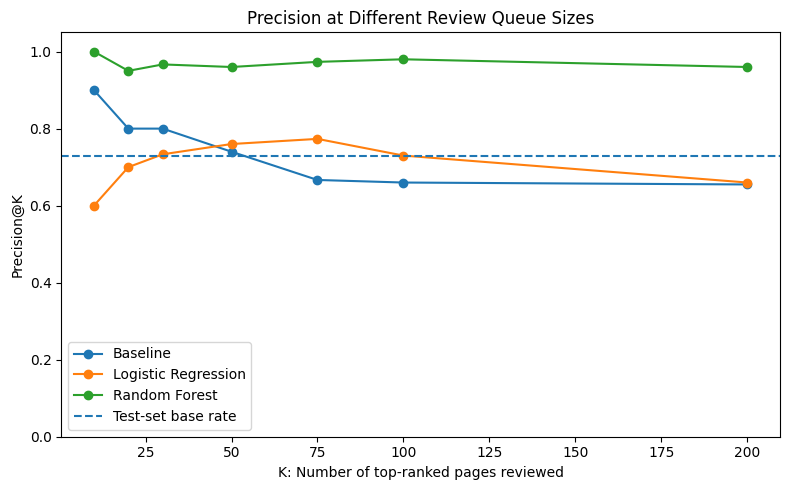

In [52]:
k_values = [10, 20, 30, 50, 75, 100, 200]

baseline_precisions = [
    precision_at_k(
        baseline_final["target_decline"],
        baseline_final["baseline_score"],
        k
    )
    for k in k_values
]

logreg_precisions = [
    precision_at_k(
        y_test_final,
        logreg_final_scores,
        k
    )
    for k in k_values
]

rf_precisions = [
    precision_at_k(
        y_test_final,
        rf_final_scores,
        k
    )
    for k in k_values
]

plt.figure(figsize=(8, 5))

plt.plot(k_values, baseline_precisions, marker="o", label="Baseline")
plt.plot(k_values, logreg_precisions, marker="o", label="Logistic Regression")
plt.plot(k_values, rf_precisions, marker="o", label="Random Forest")

plt.axhline(
    y=y_test_final.mean(),
    linestyle="--",
    label="Test-set base rate"
)

plt.xlabel("K: Number of top-ranked pages reviewed")
plt.ylabel("Precision@K")
plt.title("Precision at Different Review Queue Sizes")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

## Results

The final evaluation used a client-grouped test split, meaning that clients in the test set were not present in the training data.

The test-set decline rate was approximately **72.8%**, which serves as the base rate for comparison.

The heuristic baseline achieved **Precision@20 = 0.80** and **Precision@50 = 0.74**. Logistic Regression achieved **Precision@20 = 0.70** and **Precision@50 = 0.76**.

The Random Forest produced the strongest ranking performance, reaching **Precision@20 = 0.95** and **Precision@50 = 0.96**.

This means that 48 of the top 50 pages ranked by the Random Forest were observed to decline in the following month. The result is substantially above the test-set base rate, suggesting that the model can be useful as a prioritization tool for deciding which pages deserve manual review first.

These results should be interpreted as ranking performance rather than proof that any individual feature causes a page to decline or that refreshing a recommended page will improve search performance.

## Limitations and Honest Framing

This project is designed as a decision-support system, not a causal model.

The target represents whether a page's June impressions declined relative to May. A decline label does not automatically mean that the page should be rewritten, refreshed, merged, or removed.

The model uses historical search and content signals available before the June outcome window. Even with a client-grouped split, performance on future clients or future time periods may differ.

The minimum visibility threshold of 50 May impressions was introduced to reduce noise from very low-volume pages. This improves practical usefulness, but it also means that the model is focused on pages with at least some established search visibility.

Feature importance values describe predictive contribution within the Random Forest. They should not be interpreted as evidence that any feature directly causes rankings or traffic to change.

Search performance can also be influenced by external factors not represented in this dataset, including seasonality, competition, search demand, technical changes, and broader search-engine updates.

Therefore, the ranked output should be used to prioritize manual investigation rather than to trigger automatic content changes.

## Ranked Recommendations

The final model produces a ranked review queue rather than an automatic editing decision.

Pages near the top of the queue should be investigated first, especially when the model score is high and the page also shows signals such as high visibility, low CTR, weak average position, or older content.

Recommended actions include:

- **Prioritize content + metadata review** for high-visibility pages with low CTR.
- **Prioritize refresh review** for older pages with weak average positions.
- **Review title/snippet and intent alignment** when CTR is low but the page still has meaningful visibility.
- **Review content depth and relevance** when average position is weak.
- **Monitor** pages where the evidence is weaker.

The reason codes are intended to make the ranking easier to interpret and to help a reviewer understand why a page appears near the top of the queue.

The model score should be treated as a prioritization signal, not as a guarantee that a refresh will improve performance.

## Reproducibility and Data Credit

This capstone was built using the FlyRank ML Internship dataset and the internship warehouse release accessed through Hugging Face.

The analysis uses DuckDB for querying parquet data and scikit-learn for modeling.

Key reproducibility choices include:

- A clearly defined pre-outcome feature window
- A future comparison window for the decline target
- A minimum visibility threshold of 50 May impressions
- Client-grouped train/test splitting
- Training-only imputation for missing average-position values
- Comparison against both a heuristic baseline and Logistic Regression
- Public-safe outputs with no client names, domains, URLs, private queries, or raw exports

The full workflow is documented in this notebook and will be linked from the deployed research paper.

**Built on the FlyRank ML Internship dataset:** https://flyrank.ai